## Refinement on-the-fly of ensemble, forward model and force field
described in the Chapter 4 of the Thesis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, copy, os

In [2]:
import sys
sys.path.append('../')

from simpleMD import generate_chain, SimpleMD

### 1. MD simulation for the prior model
run a new simulation or load pre-existing simulation from `data`

In [3]:
cell = (100., 100., 100.)
positions = generate_chain(10, 1.)

In [4]:
keys_prior={
 'temperature': 0.722,
 'tstep': 0.001,
 'friction': 1.0,
 'forcecutoff': 2.5,
 'k_fene': 30.0,
 'maxbond': 1.5,
 'q_SAXS': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
 'listcutoff': 3.0,
 'nstep': 1000000,
 'nconfig': 1000,
 'nstat': 100,
 'nequilib': 10000
 }

# generate a crystal lattice and pass it:
keys_prior["cell"] = cell
keys_prior["positions"] = positions

In [5]:
is_run = False

In [6]:
if is_run:
    # create runner
    smd_prior = SimpleMD(**keys_prior)
    # run
    smd_prior.run()
else:
    with open("../data/prior.pkl", "rb") as file:
        smd_prior = pickle.load(file)

### 2. MD simulation for the reference model

In [10]:
keys_test = copy.deepcopy(keys_prior)

keys_test.update({
    'k_angle' : 5.0,
    'nconfig' : 100,
    'nstat' : 10
})

In [11]:
if is_run:
    # create runner
    smd_test=SimpleMD(**keys_test)
    # run
    smd_test.run()
else:
    with open("../data/test.pkl", "rb") as file:
        smd_test = pickle.load(file)

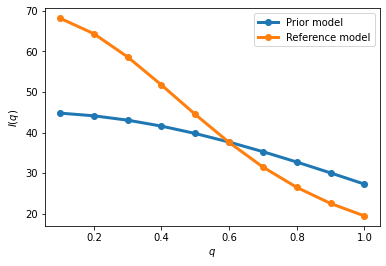

In [12]:
plt.plot(smd_prior.q_SAXS, smd_prior.SAXS, 'o-', label='Prior model', linewidth=3)
plt.plot(smd_test.q_SAXS, 1.5*smd_test.SAXS + 2.0, 'o-', label='Reference model', linewidth=3)
plt.legend()
plt.xlabel(r'$q$')
plt.ylabel(r'$I(q)$')
plt.show()

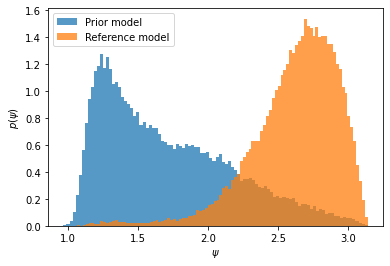

In [13]:
plt.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
plt.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Reference model')
plt.legend()
plt.xlabel(r'$\psi$')
plt.ylabel(r'$p(\psi)$')
plt.show()

### 3. refinement

In [50]:
keys_0 = copy.deepcopy(keys_prior)

keys_0.update({
    'exp_SAXS' : smd_test.SAXS,
    'sigma_SAXS' : [1.0],
    'k_ff' : 1e-4,
    'tau_ff' : 5e4,
    'l_rgyr2' : 0.0,
    'nonthefly' : int(2e6),
    'nstep' : int(3.01e6)
})

In [51]:
keys_1 = copy.deepcopy(keys_0)
keys_1['k_ff'] = 1e-3

keys_2 = copy.deepcopy(keys_0)
keys_2['k_ff'] = 1e-2

In [52]:
if is_run:
    smd_0 = SimpleMD(**keys_0)
    smd_0.run()

    smd_1 = SimpleMD(**keys_1)
    smd_1.run()

    smd_2 = SimpleMD(**keys_2)
    smd_2.run()
else:
    with open("../data/posterior_0.01_50000_ff.pkl", "rb") as file:
        smd_0 = pickle.load(file)
    
    with open("../data/posterior_0.001_50000_ff.pkl", "rb") as file:
        smd_1 = pickle.load(file)

    with open("../data/posterior_0.0001_50000_ff.pkl", "rb") as file:
        smd_2 = pickle.load(file)

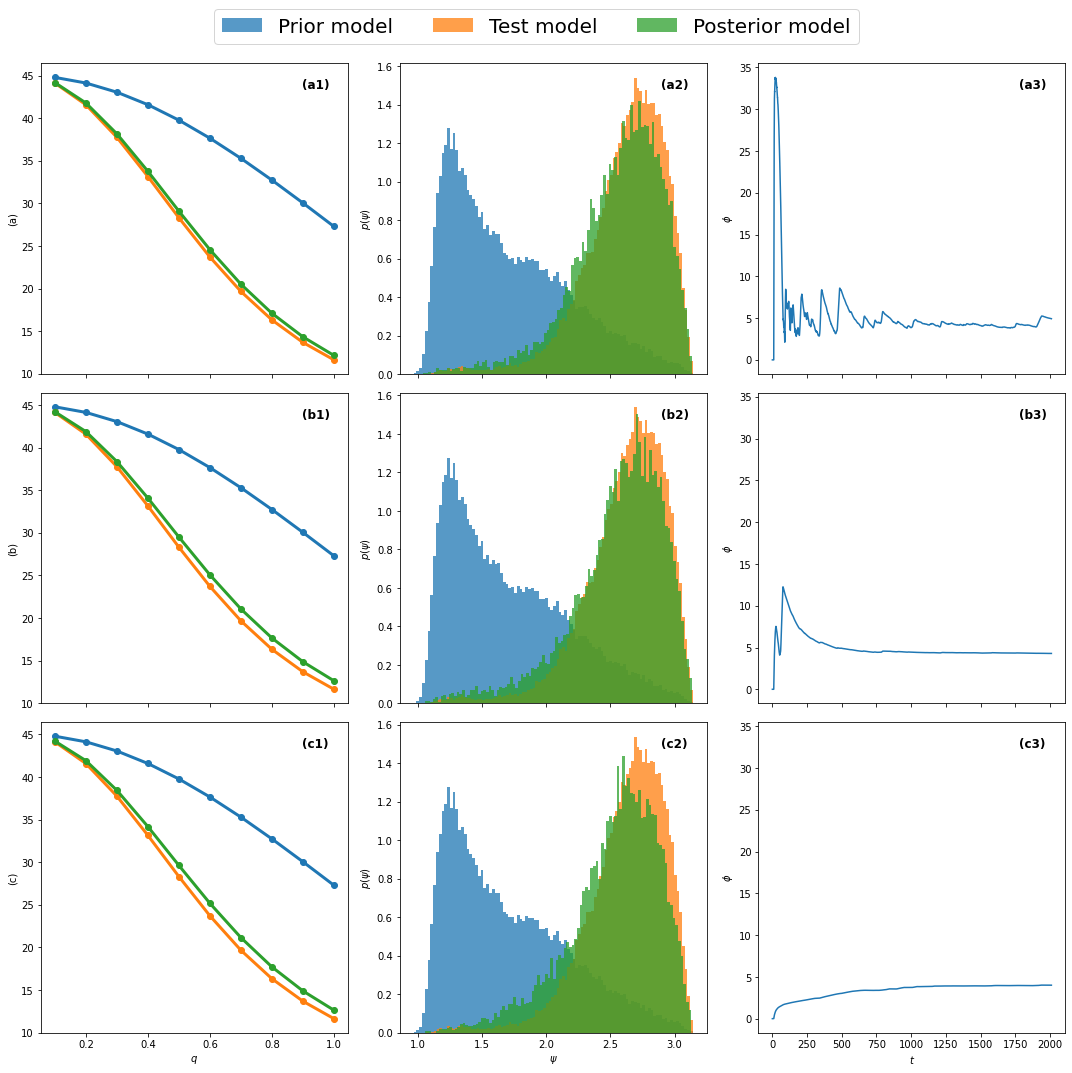

In [53]:
simulations = ["(a)", "(b)", "(c)"]
image_types = ["Tipo1", "Tipo2", "Tipo3"]
labels = [['(a1)','(a2)','(a3)'], ['(b1)','(b2)','(b3)'], ['(c1)','(c2)','(c3)']] 


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15), sharex="col", sharey="col")


for i, sim in enumerate(simulations):
  for j, img_type in enumerate(image_types):
    ax = axes[i, j]

    if j == 0:
      if i==0:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_0.exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_0.q_SAXS, smd_0.SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')

      elif i==1:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_1.exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_1.q_SAXS, smd_1.SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')


      elif i==2:
        ax.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
        ax.plot(smd_test.q_SAXS, smd_2.exp_SAXS, '-o', label='Test model',linewidth=3)
        ax.plot(smd_2.q_SAXS, smd_2.SAXS, '-o', label='Posterior model',linewidth=3)
        ax.set_ylabel(r'$I(q)$')
      
      if j == 0:
        ax.set_ylabel(sim)
    elif j == 1: 
        if i == 0: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_0.angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model')
            ax.set_ylabel(r'$p(\psi)$')
            
        elif i == 1: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_1.angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_ylabel(r'$p(\psi)$')
            
        elif i == 2: 
            ax.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
            ax.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Test model')
            ax.hist(smd_2.angle[5][-10000:], bins=100, density=True, alpha=0.75, label='Posterior model') 
            ax.set_xlabel(r'$\psi$')
            ax.set_ylabel(r'$p(\psi)$')
            
    elif j == 2: 
        if i == 0:
            ax.plot(np.array(smd_0.statistics).T[1][:20100],np.array(smd_0.statistics).T[8][:20100])
            ax.set_ylabel(r'$\phi$')
            #ax.legend()
        elif i == 1:
            ax.plot(np.array(smd_1.statistics).T[1][:20100],np.array(smd_1.statistics).T[8][:20100])
            ax.set_ylabel(r'$\phi$')
        elif i == 2:
            ax.plot(np.array(smd_2.statistics).T[1][:20100],np.array(smd_2.statistics).T[8][:20100])
            ax.set_ylabel(r'$\phi$')
        
    ax.text(0.85, 0.95, labels[i][j], transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')



axes[-1, 0].set_xlabel(r'$q$')
axes[-1, 1].set_xlabel(r'$\psi$')
axes[-1, 2].set_xlabel(r'$t$')


handles, labels_legend = axes[0,1].get_legend_handles_labels() 
fig.legend(handles, labels_legend, loc="upper center", ncol=3,fontsize=20)


plt.tight_layout(rect=[0,0,1,0.95])
plt.show()